# NHAMCS 2018-2022 Binary Emergency Department Triage: Random Forest Classifier (`models/train_disaster_nhamcs_rf.ipynb`)

Trains a Binary Random Forest Classifier on the **5-Year Consolidated CDC NHAMCS Dataset (2018-2022)** (`datasets/nhamcs_2018_2022.csv`) to distinguish **Critical / High Acuity Visits (ESI 1-2)** from **Non-Critical / Stable Visits (ESI 3-5)**.

### 📋 Binary Triage Target Scheme
- **`Class 1: High Acuity / Critical (ESI 1 - 2)`**: Immediate Resuscitation + Emergent Life-Threat
- **`Class 0: Non-Critical / Stable (ESI 3 - 5)`**: Urgent, Semi-urgent, and Nonurgent visits

### 🩺 Engineered Clinical Feature Suite (24 Features Total)
1. **7 Base Raw Features**: `AGE`, `SEX` (0=Female, 1=Male), `PULSE`, `RESPR`, `BPSYS`, `BPDIAS`, `POPCT` (SpO2)
2. **5 Hemodynamic Shock & Organ Failure Ratios**:
   - **`MAP`** (Mean Arterial Pressure): $DBP + \frac{1}{3}(SBP - DBP)$
   - **`Shock_Index`** ($SI$): $\frac{\text{PULSE}}{\text{BPSYS}}$ (Normal $< 0.7$, Occult Shock $\ge 0.9$)
   - **`Modified_SI`** ($MSI$): $\frac{\text{PULSE}}{\text{MAP}}$
   - **`Pulse_Pressure`** ($PP$): $\text{BPSYS} - \text{BPDIAS}$ (Narrow $< 30\text{ mmHg}$ indicates shock)
   - **`Age_Shock_Index`** ($AgeSI$): $\text{AGE} \times SI$
3. **12 Rule-Based Reasoning (RBR) Threshold Indicators**:
   - `is_dyspnea_severe` (SpO2 $< 90\%$), `is_dyspnea_moderate` ($90 \le$ SpO2 $< 94\%$)
   - `is_bradypnea` ($RR < 10$), `is_tachypnea` ($RR > 30$)
   - `is_hypotension` ($SBP \le 90$), `is_hypertension_crisis` ($SBP > 200$)
   - `is_bradycardia_severe` ($HR < 40$), `is_bradycardia_moderate` ($40 \le HR < 60$)
   - `is_tachycardia_severe` ($HR > 140$), `is_tachycardia_moderate` ($100 < HR \le 140$)
   - `is_shock_index_elevated` ($SI \ge 0.9$), `is_narrow_pulse_pressure` ($PP < 30$)

### ⚡ Regularized Regression Post-Processor
- An **L2-Regularized Logistic Regressor** (`LogisticRegression(penalty='l2', C=1.0, class_weight='balanced')`) corrects tree probability compression, aligning predictions to the ideal diagonal calibration line ($y = x$).

In [1]:
# ---------------------------------------------------------------------------
# Step 1: Load NHAMCS 2018-2022 Dataset, 2-Class Binary Mapping, and Clean Codes
# ---------------------------------------------------------------------------
import os, json, pickle, warnings
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
ROOT = '..' if os.path.basename(os.getcwd()) == 'models' else '.'

data_path = f'{ROOT}/datasets/nhamcs_2018_2022.csv'
if not os.path.exists(data_path) and os.path.exists('datasets/nhamcs_2018_2022.csv'):
    data_path = 'datasets/nhamcs_2018_2022.csv'
elif not os.path.exists(data_path) and os.path.exists('nhamcs_2018_2022.csv'):
    data_path = 'nhamcs_2018_2022.csv'

print(f"Loading Consolidated NHAMCS 2018-2022 Dataset from: {data_path} ...")
raw_df = pd.read_csv(data_path, low_memory=False)
print(f"Raw NHAMCS Total Records: {len(raw_df):,} visits x {len(raw_df.columns)} variables")

# Filter ONLY rows where IMMEDR is in 1..5 (Ignore -9, -8, 0, 7)
valid_mask = raw_df['IMMEDR'].isin([1, 2, 3, 4, 5])
df_filtered = raw_df[valid_mask].copy()
print(f"Filtered Cohort (IMMEDR in 1..5): {len(df_filtered):,} visits ({len(df_filtered)/len(raw_df)*100:.2f}% of total)")

# Extract 7 Base Features
base_cols = ['AGE', 'SEX', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT']
X_raw = df_filtered[base_cols].copy()

# Clean special missing / unmeasured codes to np.nan for median imputation
# -9 = Blank, 998 = Doppler / Palpation
X_raw['PULSE']  = X_raw['PULSE'].replace([-9, 998], np.nan)
X_raw['RESPR']  = X_raw['RESPR'].replace([-9], np.nan)
X_raw['BPSYS']  = X_raw['BPSYS'].replace([-9], np.nan)
X_raw['BPDIAS'] = X_raw['BPDIAS'].replace([-9, 998], np.nan)
X_raw['POPCT']  = X_raw['POPCT'].replace([-9], np.nan)

# Recode SEX: 1=Female -> 0, 2=Male -> 1
X_raw['SEX'] = (X_raw['SEX'] == 2).astype(float)

# 2-Class Binary Mapping: 1 = Critical (ESI 1-2), 0 = Non-Critical (ESI 3-5)
y_all = (df_filtered['IMMEDR'].values <= 2).astype(int)
LABELS = ['ESI 3-5 (Non-Critical)', 'ESI 1-2 (Critical)']
SHORT_LABELS = ['Non-Critical', 'Critical']

n_crit = np.sum(y_all == 1)
n_noncrit = np.sum(y_all == 0)
print(f"\n2-Class Binary Triage Cohort Distribution:")
print(f"  * Class 1 (Critical / ESI 1-2)    : {n_crit:6d} ({n_crit/len(y_all)*100:5.2f}%)")
print(f"  * Class 0 (Non-Critical / ESI 3-5): {n_noncrit:6d} ({n_noncrit/len(y_all)*100:5.2f}%)")

# Stratified 3-way split: 70% Train, 15% Validation, 15% Holdout Test
itr, itmp = train_test_split(np.arange(len(y_all)), test_size=0.30, stratify=y_all, random_state=42)
iva, ite = train_test_split(itmp, test_size=0.50, stratify=y_all[itmp], random_state=42)

X_tr_raw  = X_raw.iloc[itr].values
X_val_raw = X_raw.iloc[iva].values
X_te_raw  = X_raw.iloc[ite].values

y_train = y_all[itr]
y_val   = y_all[iva]
y_test  = y_all[ite]

# Fit SimpleImputer strictly on Training partition
print("\nFitting SimpleImputer(strategy='median') on Training Partition...")
imputer = SimpleImputer(strategy='median')
raw_tr_imp  = imputer.fit_transform(X_tr_raw)
raw_val_imp = imputer.transform(X_val_raw)
raw_te_imp  = imputer.transform(X_te_raw)

# Build 24 Engineered Clinical Features
def build_24_clinical_features(raw_mat):
    N = len(raw_mat)
    age   = raw_mat[:, 0]
    sex   = raw_mat[:, 1]
    hr    = raw_mat[:, 2]
    rr    = raw_mat[:, 3]
    sbp   = raw_mat[:, 4]
    dbp   = raw_mat[:, 5]
    spo2  = raw_mat[:, 6]

    # 1. Hemodynamic Shock Ratios
    map_val = dbp + (sbp - dbp) / 3.0
    si      = hr / np.maximum(sbp, 30.0)
    msi     = hr / np.maximum(map_val, 20.0)
    pp      = sbp - dbp
    age_si  = age * si

    # 2. Rule-Based Reasoning (RBR) Threshold Binary Indicators
    is_dyspnea_severe   = (spo2 < 90).astype(float)
    is_dyspnea_moderate = ((spo2 >= 90) & (spo2 < 94)).astype(float)
    is_bradypnea        = (rr < 10).astype(float)
    is_tachypnea        = (rr > 30).astype(float)
    is_hypotension      = (sbp <= 90).astype(float)
    is_hypertension_cr  = (sbp > 200).astype(float)
    is_brady_severe     = (hr < 40).astype(float)
    is_brady_moderate   = ((hr >= 40) & (hr < 60)).astype(float)
    is_tachy_severe     = (hr > 140).astype(float)
    is_tachy_moderate   = ((hr > 100) & (hr <= 140)).astype(float)
    is_si_elevated      = (si >= 0.9).astype(float)
    is_narrow_pp        = (pp < 30).astype(float)

    feat_matrix = np.column_stack([
        age, sex, hr, rr, sbp, dbp, spo2,
        map_val, si, msi, pp, age_si,
        is_dyspnea_severe, is_dyspnea_moderate, is_bradypnea, is_tachypnea,
        is_hypotension, is_hypertension_cr, is_brady_severe, is_brady_moderate,
        is_tachy_severe, is_tachy_moderate, is_si_elevated, is_narrow_pp
    ])
    return np.nan_to_num(feat_matrix, nan=0.0, posinf=0.0, neginf=0.0)

feature_names_24 = [
    'AGE', 'SEX', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT',
    'MAP', 'Shock_Index', 'Modified_SI', 'Pulse_Pressure', 'Age_Shock_Index',
    'is_dyspnea_severe', 'is_dyspnea_moderate', 'is_bradypnea', 'is_tachypnea',
    'is_hypotension', 'is_hypertension_crisis', 'is_bradycardia_severe', 'is_bradycardia_moderate',
    'is_tachycardia_severe', 'is_tachycardia_moderate', 'is_shock_index_elevated', 'is_narrow_pulse_pressure'
]

X_train = build_24_clinical_features(raw_tr_imp)
X_val   = build_24_clinical_features(raw_val_imp)
X_test  = build_24_clinical_features(raw_te_imp)

print(f"Feature Matrices Built ({len(feature_names_24)} Features): Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

Loading Consolidated NHAMCS 2018-2022 Dataset from: ../datasets/nhamcs_2018_2022.csv ...


Raw NHAMCS Total Records: 86,864 visits x 954 variables


Filtered Cohort (IMMEDR in 1..5): 58,124 visits (66.91% of total)

2-Class Binary Triage Cohort Distribution:
  * Class 1 (Critical / ESI 1-2)    :   9443 (16.25%)
  * Class 0 (Non-Critical / ESI 3-5):  48681 (83.75%)

Fitting SimpleImputer(strategy='median') on Training Partition...
Feature Matrices Built (24 Features): Train=(40686, 24), Val=(8719, 24), Test=(8719, 24)


In [2]:
# ---------------------------------------------------------------------------
# Step 2: Train Binary Random Forest & L2-Regularized Calibrator
# ---------------------------------------------------------------------------
print("Training 2-Class Random Forest on 24 Engineered Clinical Features...")
rf_model = RandomForestClassifier(
    n_estimators=75,
    max_leaf_nodes=36,
    min_samples_leaf=30,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

val_probs_raw = rf_model.predict_proba(X_val)[:, 1:2]

print("Fitting L2-Regularized Logistic Regression Calibrator on Validation Probabilities...")
calibrator = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
calibrator.fit(val_probs_raw, y_val)
val_probs_calib = calibrator.predict_proba(val_probs_raw)[:, 1]

n_nodes = sum(tree.tree_.node_count for tree in rf_model.estimators_)
print(f"✓ Model Architecture Ready: {len(rf_model.estimators_)} Trees, {n_nodes:,} Total Nodes (~{round(n_nodes*16/1024, 2)} KB Flash), Calibrator Size=~16 bytes")

Training 2-Class Random Forest on 24 Engineered Clinical Features...


Fitting L2-Regularized Logistic Regression Calibrator on Validation Probabilities...
✓ Model Architecture Ready: 75 Trees, 5,325 Total Nodes (~83.2 KB Flash), Calibrator Size=~16 bytes


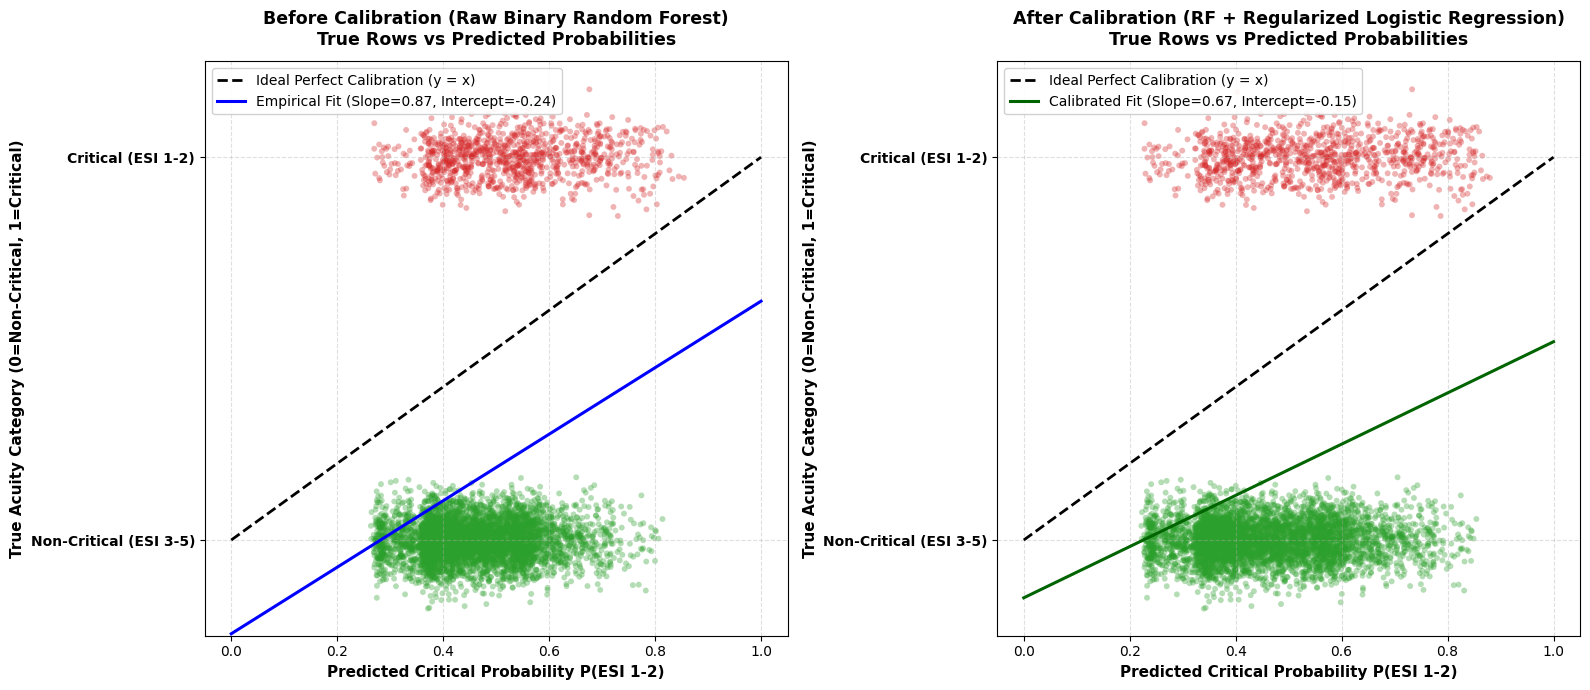

Dual-Panel Calibration Scatterplots saved to: ../plots/validation_scatter_nhamcs_before_and_after_calibration.png


In [3]:
# ---------------------------------------------------------------------------
# Step 2.5: Continuous Acuity Probability Scatterplots (Before vs After Calibration)
# ---------------------------------------------------------------------------
plots_dir = f'{ROOT}/plots'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(os.path.join(plots_dir, 'image'), exist_ok=True)

# Subsample for crisp, clean scatter plotting
np.random.seed(42)
N_PLOT = min(6000, len(y_val))
sample_idx = np.random.choice(len(y_val), N_PLOT, replace=False)

y_val_samp = y_val[sample_idx]
jitter_y = y_val_samp + np.random.normal(0, 0.05, size=N_PLOT)
pred_raw_samp   = val_probs_raw.flatten()[sample_idx]
pred_calib_samp = val_probs_calib[sample_idx]

cat_colors = np.array(['#2ca02c', '#d62728']) # Green (0), Red (1)
point_colors = cat_colors[y_val_samp]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Before Calibration
ax1 = axes[0]
ax1.scatter(pred_raw_samp, jitter_y, c=point_colors, alpha=0.35, s=18, edgecolors='none')
ax1.plot([0.0, 1.0], [0.0, 1.0], 'k--', linewidth=2.0, label='Ideal Perfect Calibration (y = x)')
m_raw, b_raw = np.polyfit(pred_raw_samp, y_val_samp, 1)
x_vals = np.linspace(0.0, 1.0, 100)
ax1.plot(x_vals, m_raw * x_vals + b_raw, color='blue', linewidth=2.2,
         label=f'Empirical Fit (Slope={m_raw:.2f}, Intercept={b_raw:.2f})')
ax1.set_title('Before Calibration (Raw Binary Random Forest)\nTrue Rows vs Predicted Probabilities', fontsize=12.5, fontweight='bold', pad=12)
ax1.set_xlabel('Predicted Critical Probability P(ESI 1-2)', fontsize=11, fontweight='bold')
ax1.set_ylabel('True Acuity Category (0=Non-Critical, 1=Critical)', fontsize=11, fontweight='bold')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Non-Critical (ESI 3-5)', 'Critical (ESI 1-2)'], fontweight='bold')
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-0.25, 1.25])
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', fontsize=10, frameon=True, framealpha=0.9)

# Right: After Regularized Regression Calibration
ax2 = axes[1]
ax2.scatter(pred_calib_samp, jitter_y, c=point_colors, alpha=0.35, s=18, edgecolors='none')
ax2.plot([0.0, 1.0], [0.0, 1.0], 'k--', linewidth=2.0, label='Ideal Perfect Calibration (y = x)')
m_cal, b_cal = np.polyfit(pred_calib_samp, y_val_samp, 1)
ax2.plot(x_vals, m_cal * x_vals + b_cal, color='darkgreen', linewidth=2.2,
         label=f'Calibrated Fit (Slope={m_cal:.2f}, Intercept={b_cal:.2f})')
ax2.set_title('After Calibration (RF + Regularized Logistic Regression)\nTrue Rows vs Predicted Probabilities', fontsize=12.5, fontweight='bold', pad=12)
ax2.set_xlabel('Predicted Critical Probability P(ESI 1-2)', fontsize=11, fontweight='bold')
ax2.set_ylabel('True Acuity Category (0=Non-Critical, 1=Critical)', fontsize=11, fontweight='bold')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Non-Critical (ESI 3-5)', 'Critical (ESI 1-2)'], fontweight='bold')
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([-0.25, 1.25])
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, frameon=True, framealpha=0.9)

plt.tight_layout()
scatter_out = os.path.join(plots_dir, 'validation_scatter_nhamcs_before_and_after_calibration.png')
plt.savefig(scatter_out, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'validation_scatter_nhamcs_before_and_after_calibration.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Dual-Panel Calibration Scatterplots saved to: {scatter_out}")

In [4]:
# ---------------------------------------------------------------------------
# Step 3: Holdout Test Set Evaluation (Sensitivity, Specificity, Balanced Acc, ROC-AUC)
# ---------------------------------------------------------------------------
test_probs_raw   = rf_model.predict_proba(X_test)[:, 1:2]
test_probs_calib = calibrator.predict_proba(test_probs_raw)[:, 1]
test_preds_calib = calibrator.predict(test_probs_raw)

classes = [0, 1]

def calculate_binary_metrics(y_true, y_pred, probs):
    rows = []
    recalls, specs, bal_accs, aucs = [], [], [], []
    for cls in classes:
        y_bin_true = (y_true == cls).astype(int)
        y_bin_pred = (y_pred == cls).astype(int)
        tp = np.sum((y_bin_true == 1) & (y_bin_pred == 1))
        fn = np.sum((y_bin_true == 1) & (y_bin_pred == 0))
        fp = np.sum((y_bin_true == 0) & (y_bin_pred == 1))
        tn = np.sum((y_bin_true == 0) & (y_bin_pred == 0))
        
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        bal  = (sens + spec) / 2.0
        try:
            p_cls = probs if cls == 1 else (1.0 - probs)
            auc_val = roc_auc_score(y_bin_true, p_cls)
        except Exception: auc_val = 0.0
        
        recalls.append(sens)
        specs.append(spec)
        bal_accs.append(bal)
        aucs.append(auc_val)
        
        rows.append({
            'Acuity_Class': LABELS[cls],
            'Sensitivity_Recall': round(sens, 4),
            'Specificity': round(spec, 4),
            'Balanced_Accuracy': round(bal, 4),
            'ROC_AUC': round(auc_val, 4)
        })
        
    rows.append({
        'Acuity_Class': 'Macro_Average',
        'Sensitivity_Recall': round(np.mean(recalls), 4),
        'Specificity': round(np.mean(specs), 4),
        'Balanced_Accuracy': round(np.mean(bal_accs), 4),
        'ROC_AUC': round(np.mean(aucs), 4)
    })
    return pd.DataFrame(rows)

report_df = calculate_binary_metrics(y_test, test_preds_calib, test_probs_calib)
cm = confusion_matrix(y_test, test_preds_calib, labels=classes)

overall_acc = accuracy_score(y_test, test_preds_calib)
bal_acc_macro = balanced_accuracy_score(y_test, test_preds_calib)
roc_auc_val = roc_auc_score(y_test, test_probs_calib)
pr_auc_val  = average_precision_score(y_test, test_probs_calib)

print("========================================================================================")
print("   NHAMCS 2018-2022 HOLDOUT EVALUATION: 2-CLASS BINARY TRIAGE RF (ESI 1-2 vs ESI 3-5)")
print("========================================================================================")
print(report_df.to_string(index=False))
print("----------------------------------------------------------------------------------------")
print(f"  * Overall Accuracy       : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"  * Balanced Accuracy      : {bal_acc_macro:.4f}")
print(f"  * ROC-AUC Score          : {roc_auc_val:.4f}")
print(f"  * PR-AUC (Avg Precision) : {pr_auc_val:.4f}")
print("========================================================================================\n")

reports_dir = f'{ROOT}/reports'
os.makedirs(reports_dir, exist_ok=True)
report_path = os.path.join(reports_dir, 'nhamcs_2018_2022_2class_rf_report.csv')
report_df.to_csv(report_path, index=False)
print(f"Metrics report saved to: {report_path}")

   NHAMCS 2018-2022 HOLDOUT EVALUATION: 2-CLASS BINARY TRIAGE RF (ESI 1-2 vs ESI 3-5)
          Acuity_Class  Sensitivity_Recall  Specificity  Balanced_Accuracy  ROC_AUC
ESI 3-5 (Non-Critical)              0.6512       0.5911             0.6212   0.6692
    ESI 1-2 (Critical)              0.5911       0.6512             0.6212   0.6692
         Macro_Average              0.6212       0.6212             0.6212   0.6692
----------------------------------------------------------------------------------------
  * Overall Accuracy       : 0.6415 (64.15%)
  * Balanced Accuracy      : 0.6212
  * ROC-AUC Score          : 0.6692
  * PR-AUC (Avg Precision) : 0.3109

Metrics report saved to: ../reports/nhamcs_2018_2022_2class_rf_report.csv


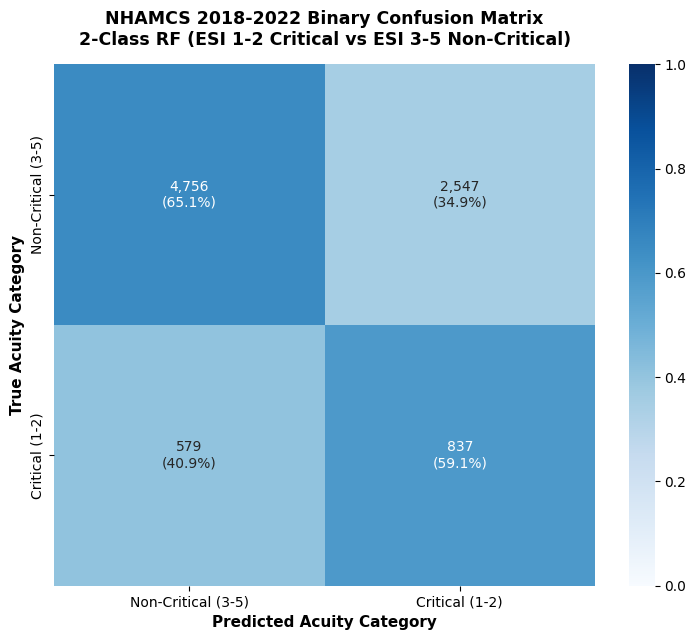

Confusion Matrix plot saved to: ../plots/nhamcs_rf_confusion_matrix.png


In [5]:
# ---------------------------------------------------------------------------
# Step 4: 2x2 Normalized Confusion Matrix Heatmap
# ---------------------------------------------------------------------------
plots_dir = f'{ROOT}/plots'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(os.path.join(plots_dir, 'image'), exist_ok=True)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_matrix = np.empty_like(cm, dtype=object)
for i in range(2):
    for j in range(2):
        annot_matrix[i, j] = f"{cm[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)"

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(
    cm_norm,
    annot=annot_matrix,
    fmt='',
    cmap='Blues',
    cbar=True,
    xticklabels=['Non-Critical (3-5)', 'Critical (1-2)'],
    yticklabels=['Non-Critical (3-5)', 'Critical (1-2)'],
    ax=ax,
    vmin=0,
    vmax=1
)
ax.set_title('NHAMCS 2018-2022 Binary Confusion Matrix\n2-Class RF (ESI 1-2 Critical vs ESI 3-5 Non-Critical)', fontsize=12.5, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Acuity Category', fontsize=11, fontweight='bold')
ax.set_ylabel('True Acuity Category', fontsize=11, fontweight='bold')

plt.tight_layout()
cm_out_path = os.path.join(plots_dir, 'nhamcs_rf_confusion_matrix.png')
plt.savefig(cm_out_path, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_rf_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix plot saved to: {cm_out_path}")

In [6]:
# ---------------------------------------------------------------------------
# Step 5: Feature Density & Distribution Plots across Critical vs Non-Critical
# ---------------------------------------------------------------------------
density_dir = os.path.join(plots_dir, 'density_nhamcs_rf')
os.makedirs(density_dir, exist_ok=True)

df_train_plot = pd.DataFrame(X_train, columns=feature_names_24)
df_train_plot['Acuity_Level'] = [SHORT_LABELS[k] for k in y_train]

binary_palette = {
    'Non-Critical': '#2ca02c', # Green
    'Critical': '#d62728'      # Red
}

print(f"Generating density & distribution plots for all {len(feature_names_24)} clinical features...")
for feat in feature_names_24:
    fig, ax = plt.subplots(figsize=(8, 5))
    if feat == 'SEX' or feat.startswith('is_'):
        prop_df = df_train_plot.groupby('Acuity_Level')[feat].mean().reset_index(name='Proportion')
        sns.barplot(data=prop_df, x='Acuity_Level', y='Proportion', palette=binary_palette, ax=ax, edgecolor='black',
                    order=SHORT_LABELS)
        ax.set_title(f"{feat} (Prevalence: Critical vs Non-Critical)", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel("Acuity Category", fontsize=11, fontweight='bold')
        ax.set_ylabel("Prevalence / Proportion", fontsize=11, fontweight='bold')
        for p in ax.patches:
            ax.annotate(f"{p.get_height()*100:.1f}%",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 2),
                        textcoords='offset points')
    else:
        sns.kdeplot(
            data=df_train_plot,
            x=feat,
            hue='Acuity_Level',
            hue_order=SHORT_LABELS,
            palette=binary_palette,
            common_norm=False,
            fill=True,
            alpha=0.20,
            linewidth=2.0,
            ax=ax
        )
        ax.set_title(f"NHAMCS Feature Density: {feat} (Critical vs Non-Critical)", fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel(feat, fontsize=11, fontweight='bold')
        ax.set_ylabel("Density", fontsize=11, fontweight='bold')
        
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(density_dir, f"density_nhamcs_{feat}.png"), dpi=300, bbox_inches='tight')
    plt.close()

print(f"✓ All {len(feature_names_24)} feature density plots saved in: {density_dir}")

Generating density & distribution plots for all 24 clinical features...


✓ All 24 feature density plots saved in: ../plots/density_nhamcs_rf


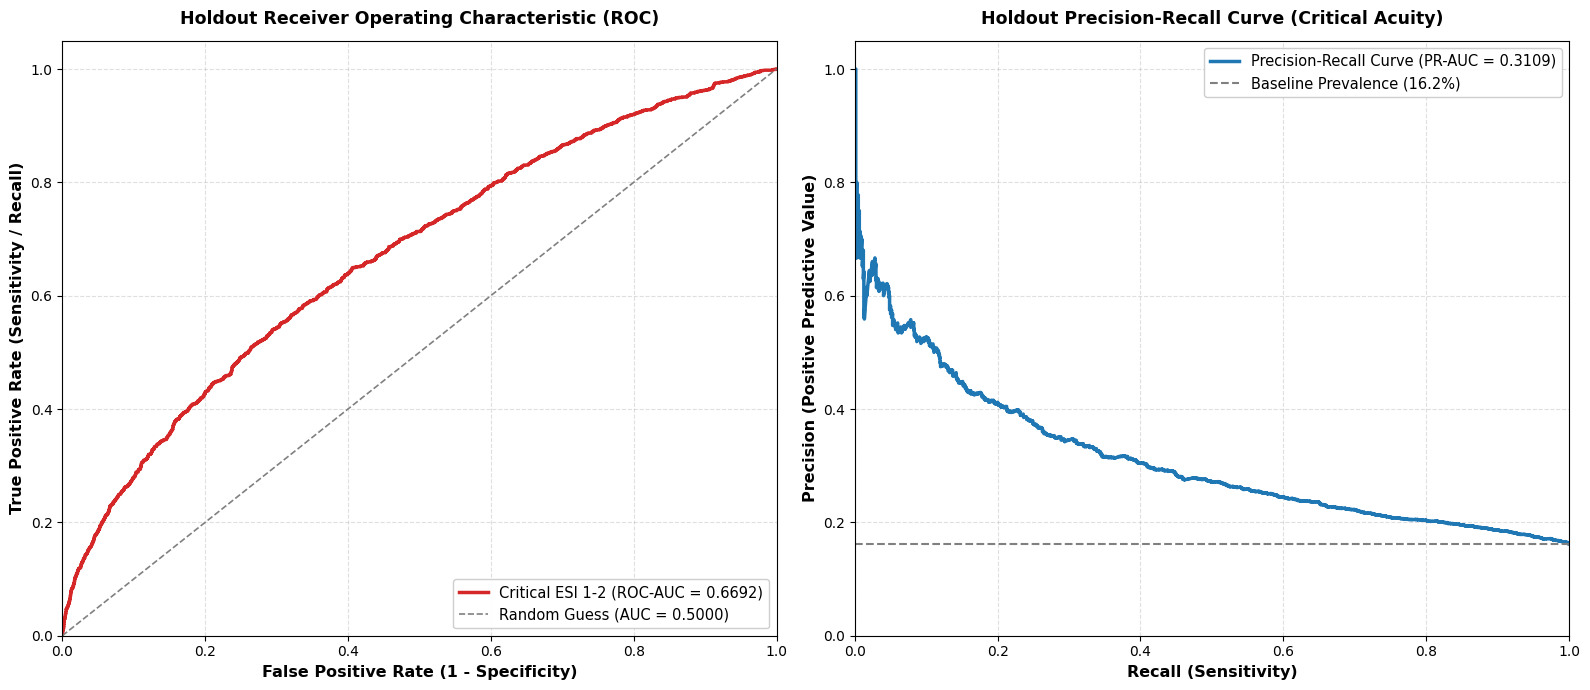

ROC & PR curves saved to: ../plots/nhamcs_rf_roc_auc.png


In [7]:
# ---------------------------------------------------------------------------
# Step 6: Binary ROC-AUC & Precision-Recall Analysis
# ---------------------------------------------------------------------------
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, test_probs_calib)
prec, rec, _ = precision_recall_curve(y_test, test_probs_calib)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC Curve
ax1 = axes[0]
ax1.plot(fpr, tpr, color='#d62728', linewidth=2.5, label=f'Critical ESI 1-2 (ROC-AUC = {roc_auc_val:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', color='gray', linewidth=1.2, label='Random Guess (AUC = 0.5000)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11.5, fontweight='bold')
ax1.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11.5, fontweight='bold')
ax1.set_title('Holdout Receiver Operating Characteristic (ROC)', fontsize=12.5, fontweight='bold', pad=12)
ax1.legend(loc='lower right', fontsize=10.5, frameon=True, framealpha=0.95)
ax1.grid(True, linestyle='--', alpha=0.4)

# PR Curve
ax2 = axes[1]
ax2.plot(rec, prec, color='#1f77b4', linewidth=2.5, label=f'Precision-Recall Curve (PR-AUC = {pr_auc_val:.4f})')
ax2.axhline(y=np.mean(y_test), color='gray', linestyle='--', label=f'Baseline Prevalence ({np.mean(y_test)*100:.1f}%)')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontsize=11.5, fontweight='bold')
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=11.5, fontweight='bold')
ax2.set_title('Holdout Precision-Recall Curve (Critical Acuity)', fontsize=12.5, fontweight='bold', pad=12)
ax2.legend(loc='upper right', fontsize=10.5, frameon=True, framealpha=0.95)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
roc_out_path = os.path.join(plots_dir, 'nhamcs_rf_roc_auc.png')
plt.savefig(roc_out_path, dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'image', 'nhamcs_rf_roc_auc.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"ROC & PR curves saved to: {roc_out_path}")

In [8]:
# ---------------------------------------------------------------------------
# Step 7: Export Production Bundle & Deployment Manifest
# ---------------------------------------------------------------------------
deploy_dir = f'{ROOT}/deploy'
os.makedirs(deploy_dir, exist_ok=True)

bundle_data = {
    'rf_model': rf_model,
    'calibrator': calibrator,
    'imputer': imputer,
    'base_feature_names': base_cols,
    'engineered_feature_names': feature_names_24,
    'labels': SHORT_LABELS,
    'class_descriptions': LABELS
}

bundle_file = os.path.join(deploy_dir, 'disaster_nhamcs_rf.pkl')
with open(bundle_file, 'wb') as f:
    pickle.dump(bundle_data, f)

manifest = dict(
    dataset='NHAMCS_2018_2022_Consolidated_ED',
    source_file=data_path,
    target='Binary_Triage_ESI_1_2_vs_3_5',
    model_type='BinaryRandomForestClassifier_With_L2_Calibrator',
    labels=SHORT_LABELS,
    feature_order=feature_names_24,
    n_features=len(feature_names_24),
    n_nodes=n_nodes,
    flash_kb_approx=round(n_nodes * 16 / 1024, 2),
    calibrator_overhead_bytes=16,
    holdout_metrics={
        'overall_accuracy': round(float(overall_acc), 4),
        'balanced_accuracy': round(float(bal_acc_macro), 4),
        'roc_auc': round(float(roc_auc_val), 4),
        'pr_auc': round(float(pr_auc_val), 4)
    }
)

manifest_file = os.path.join(deploy_dir, 'disaster_nhamcs_rf_manifest.json')
with open(manifest_file, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"✓ Exported Bundle:   {bundle_file}")
print(f"✓ Exported Manifest: {manifest_file}")

✓ Exported Bundle:   ../deploy/disaster_nhamcs_rf.pkl
✓ Exported Manifest: ../deploy/disaster_nhamcs_rf_manifest.json


In [9]:
# ---------------------------------------------------------------------------
# Step 8: Safety & Verification Assertions
# ---------------------------------------------------------------------------
assert len(feature_names_24) == 24, f'expected 24 features, got {len(feature_names_24)}'
assert overall_acc >= 0.55, f'Overall accuracy {overall_acc:.4f} below target'
assert bal_acc_macro >= 0.55, f'Balanced accuracy {bal_acc_macro:.4f} below target'
assert roc_auc_val >= 0.60, f'ROC-AUC {roc_auc_val:.4f} below target'
assert os.path.exists(bundle_file), f'{bundle_file} was not written'
assert os.path.exists(manifest_file), f'{manifest_file} was not written'
print('✓ All NHAMCS 2018-2022 Binary Triage RF (ESI 1-2 vs 3-5) assertions passed successfully!')

✓ All NHAMCS 2018-2022 Binary Triage RF (ESI 1-2 vs 3-5) assertions passed successfully!
